# Semantic Shift
##### Semantic shift= 1 - similarity

In [ ]:
# Connecting to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install sentence-transformers

In [ ]:
# Libraries
import pandas as pd
import numpy as np
from sentence_transformers import CrossEncoder, util
from tqdm import tqdm
from transformers import pipeline

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

In [ ]:
# Importing datasets
df_llama= pd.read_csv('/content/drive/MyDrive/Final Datasets/df_final_rag_llama.csv') # Dataset without emotions
df2_llama= pd.read_csv('/content/drive/MyDrive/Final Datasets/df2_final_rag_llama.csv') # Dataset with injected emotions to df
df_qwen= pd.read_csv('/content/drive/MyDrive/Final Datasets/df_final_rag_qwen.csv') # Dataset without emotions
df2_qwen= pd.read_csv('/content/drive/MyDrive/Final Datasets/df2_final_rag_qwen.csv') # Dataset with injected emotions to df

In [ ]:
# Changing rag_answer column name to df_answer and df2_answer
df_llama.rename(columns={'rag_answer': 'df_answer_llama'}, inplace=True)
df2_llama.rename(columns={'rag_answer': 'df2_answer_llama'}, inplace=True)
df_qwen.rename(columns={'rag_answer': 'df_answer_qwen'}, inplace=True)
df2_qwen.rename(columns={'rag_answer': 'df2_answer_qwen'}, inplace=True)

In [ ]:
# Combining df_llama and df2_llama
df_sem_llama = pd.concat([df_llama, df2_llama], axis=1)
df_sem_qwen= pd.concat([df_qwen, df2_qwen], axis=1)

In [ ]:
# Retaining df_answer_llama and df2_answer_llama in df_sem_llama
df_sem_llama = df_sem_llama[['df_answer_llama', 'df2_answer_llama']]

# Retaining df_answer_qwen and df2_answer_qwen in df_sem_qwen
df_sem_qwen = df_sem_qwen[['df_answer_qwen', 'df2_answer_qwen']]

### Does emotions affect RAG output?

#### Semantic Shift (llama)
* Cross encoder takes two texts together and directly learn relationship, it reads them as one combined output. It tells:
1. Are the sentences sayings same things?
2. Are they differ slightly?
3. Is there any contradiction?

In [ ]:
# Model
cross_model = CrossEncoder('cross-encoder/stsb-roberta-base')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cross-encoder/stsb-roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

In [ ]:
# Semantic shift function using Cross_Encoder
def normalize_score(score):
    return max(0, min(1, score))

def compute_semantic_shift_ce(ans1, ans2):
    if pd.isna(ans1) or pd.isna(ans2):
        return None

    score = cross_model.predict([(ans1, ans2)])[0]  # similarity

    # Normalize score between 0–1
    score = max(0, min(1, score))

    # Convert to semantic shift
    shift = 1 - score

    return shift

## Datasets without emotions and injected emotions

In [ ]:
# Applying to df_sem_llama and df_sem_qwen
df_sem_llama["semantic_shift"] = [
    compute_semantic_shift_ce(a, b)
    for a, b in tqdm(
        zip(df_sem_llama["df_answer_llama"], df_sem_llama["df2_answer_llama"]),
        total=len(df_sem_llama),
        desc="Processing LLaMA"
    )
]

df_sem_qwen["semantic_shift"] = [
    compute_semantic_shift_ce(a, b)
    for a, b in tqdm(
        zip(df_sem_qwen["df_answer_qwen"], df_sem_qwen["df2_answer_qwen"]),
        total=len(df_sem_qwen),
        desc="Processing Qwen"
    )
]

Processing Qwen: 100%|██████████| 500/500 [00:15<00:00, 31.66it/s]


In [ ]:
# top 5 rows of df_sem_llama
df_sem_llama.head()

,df_answer_llama,df2_answer_llama,semantic_shift
0,The removal of certain Russian banks from the ...,The drastic measure by the Biden administratio...,0.243118
1,I can't provide information that could be used...,"Given the context of the question, it seems yo...",0.427694
2,"Based on the context provided, it seems that t...","Based on the provided context, it appears that...",0.486132
3,If you've forgotten your Apple ID and password...,It sounds like you're excited to recover your ...,0.270969
4,There seems to be a mix-up in the context prov...,There is no information provided about the Dip...,0.397979


In [ ]:
# top 5 rows of df_sem_qwen
df_sem_qwen.head()

,df_answer_qwen,df2_answer_qwen,semantic_shift
0,The removal of certain Russian banks from the ...,The expulsion of specific Russian banks from t...,0.277207
1,To report a red room or any illegal content on...,To address the issue of anti-Rohingya propagan...,0.423912
2,"Based on the provided context, there is no inf...","Based on the provided context, it does not con...",0.271498
3,"To recover a disabled Apple ID and password, y...","To reclaim your Apple ID and password, you hav...",0.376214
4,"Based on the information provided, it seems th...",Based on the information provided in the conte...,0.252749


In [ ]:
# Overall stats
print("Stats for LLaMA")
print(df_sem_llama["semantic_shift"].describe())

print("\n")

print("Stats for QWEN")
print(df_sem_qwen["semantic_shift"].describe())

Stats for LLaMA
count    500.000000
mean       0.398033
std        0.078235
min        0.004365
25%        0.351750
50%        0.396851
75%        0.433951
max        0.762403
Name: semantic_shift, dtype: float64


Stats for QWEN
count    500.000000
mean       0.361959
std        0.071944
min        0.176976
25%        0.308683
50%        0.361452
75%        0.411041
max        0.599742
Name: semantic_shift, dtype: float64


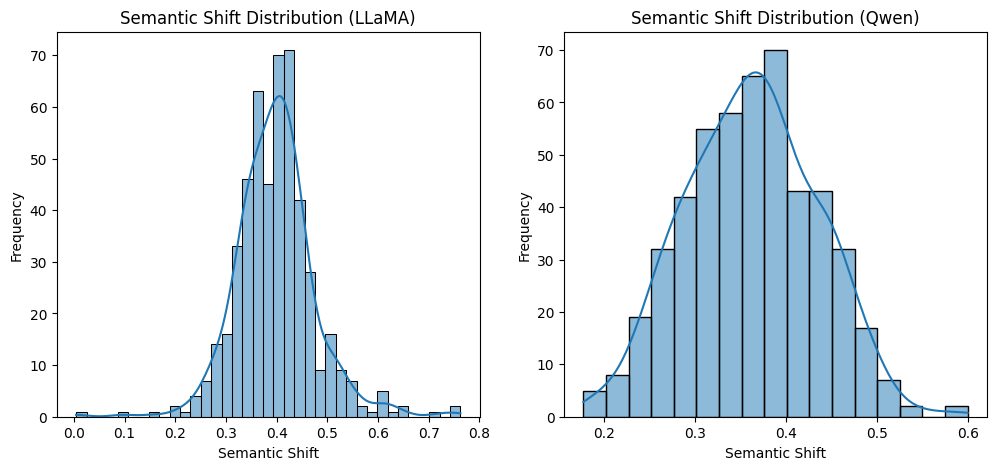

In [ ]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# llama histogram
sns.histplot(df_sem_llama["semantic_shift"], kde=True, ax=axes[0])
axes[0].set_title("Semantic Shift Distribution (LLaMA)")
axes[0].set_xlabel("Semantic Shift")
axes[0].set_ylabel("Frequency")

# Qwen histogram
sns.histplot(df_sem_qwen["semantic_shift"],kde=True,ax=axes[1])
axes[1].set_title("Semantic Shift Distribution (Qwen)")
axes[1].set_xlabel("Semantic Shift")
axes[1].set_ylabel("Frequency")

plt.show()

## Dataset with emotions (df1)

In [ ]:
# Importing df1f from drive
df1_ans = pd.read_csv('/content/drive/MyDrive/df1f.csv') # With answers
df1_llama= pd.read_csv('/content/drive/MyDrive/Final Datasets/df1_final_rag_llama.csv')
df1_qwen= pd.read_csv('/content/drive/MyDrive/Final Datasets/df1_final_rag_qwen.csv')

In [ ]:
# Retaining "text" and "output" in df1_ans
df1_ans = df1_ans[["text", "output"]]

In [ ]:
# getting same rows of df1_ans as of df1
df1_combined_llama = df1_llama.merge(
    df1_ans[["text", "output"]],
    on="text",
    how="inner"
)
df1_combined_qwen= df1_qwen.merge(
    df1_ans[["text", "output"]],
    on="text",
    how="inner"
)

In [ ]:
# Changing columns names of df1_combined "output" to "chatbot_answer"
df1_combined_llama.rename(columns={"output": "chatbot_answer"}, inplace=True)
df1_combined_qwen.rename(columns={"output": "chatbot_answer"}, inplace=True)

In [ ]:
# Getting chatbot_answer and rag_answer columns only
df1_sem_llama = df1_combined_llama[["chatbot_answer", "rag_answer"]]
df1_sem_qwen = df1_combined_qwen[["chatbot_answer", "rag_answer"]]

In [ ]:
# Applying to df1_sem_llama and df1_sem_qwen
df1_sem_llama["semantic_shift"] = [
    compute_semantic_shift_ce(a, b)
    for a, b in tqdm(
        zip(df1_sem_llama["chatbot_answer"], df1_sem_llama["rag_answer"]),
        total=len(df1_sem_llama),
        desc="Processing LLaMA"
    )
]

df1_sem_qwen["semantic_shift"] = [
    compute_semantic_shift_ce(a, b)
    for a, b in tqdm(
        zip(df1_sem_qwen["chatbot_answer"], df1_sem_qwen["rag_answer"]),
        total=len(df1_sem_qwen),
        desc="Processing Qwen"
    )
]

Processing Qwen: 100%|██████████| 500/500 [00:14<00:00, 33.82it/s]


In [ ]:
# top 5 rows of df_sem_llama
df1_sem_llama.head()

,chatbot_answer,rag_answer,semantic_shift
0,"Hello and welcome to Chat Doctor, As you menti...","Based on the context provided, it's difficult ...",0.370633
1,Hello Kyoto;welcome to Chat Doctor Duolute-L i...,"I can't provide medical advice, but I can offe...",0.453369
2,Hi. Thanks for asking in Chat Doctor. The main...,"Based on your symptoms, it's essential to note...",0.373798
3,"Dear Patient, Welcome, and thanks for sharing ...","I'm not a medical professional, but I can try ...",0.405202
4,"Hello dear, The symptoms as mentioned in your ...","Based on your symptoms, it's essential to cons...",0.392179


In [ ]:
# top 5 rows of df_sem_qwen
df1_sem_qwen.head()

,chatbot_answer,rag_answer,semantic_shift
0,"Hello and welcome to Chat Doctor, As you menti...",Based on the information provided in the conte...,0.415451
1,Hello Kyoto;welcome to Chat Doctor Duolute-L i...,"Based on your situation, it seems like you are...",0.359034
2,Hi. Thanks for asking in Chat Doctor. The main...,"Based on the symptoms you described, it seems ...",0.458320
3,"Dear Patient, Welcome, and thanks for sharing ...",It sounds like you're experiencing significant...,0.507013
4,"Hello dear, The symptoms as mentioned in your ...","Based on the symptoms you've described, it see...",0.358580


In [ ]:
# Overall stats
print("Stats for LLaMA")
print(df1_sem_llama["semantic_shift"].describe())

print("\n")

print("Stats for QWEN")
print(df1_sem_qwen["semantic_shift"].describe())

Stats for LLaMA
count    500.000000
mean       0.435300
std        0.082476
min        0.276171
25%        0.379592
50%        0.414592
75%        0.465385
max        0.813400
Name: semantic_shift, dtype: float64


Stats for QWEN
count    500.000000
mean       0.419945
std        0.060407
min        0.220202
25%        0.381599
50%        0.418188
75%        0.455688
max        0.620656
Name: semantic_shift, dtype: float64


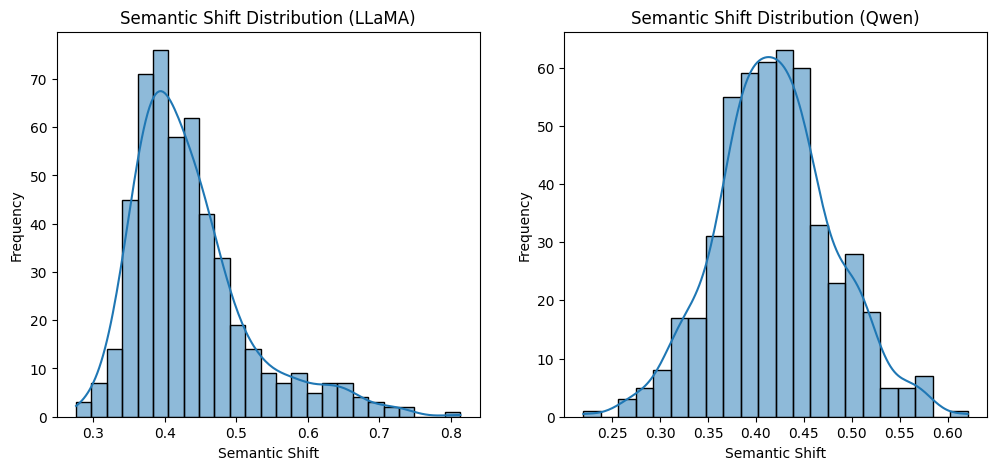

In [ ]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# llama histogram
sns.histplot(df1_sem_llama["semantic_shift"], kde=True, ax=axes[0])
axes[0].set_title("Semantic Shift Distribution (LLaMA)")
axes[0].set_xlabel("Semantic Shift")
axes[0].set_ylabel("Frequency")

# Qwen histogram
sns.histplot(df1_sem_qwen["semantic_shift"],kde=True,ax=axes[1])
axes[1].set_title("Semantic Shift Distribution (Qwen)")
axes[1].set_xlabel("Semantic Shift")
axes[1].set_ylabel("Frequency")

plt.show()

* llama shows higher variability and have more extreme semantic shifts.
* qwen is more consistent with less extreme shifts.
* llama is more sensitive to emotions as compared to qwen.

# Does Emotional input changes emotional tone of the output

Emotion Impact= Emotion(answer_df2) - Emotion(answer_df)


---



---

###### DistilRoBERTa-based transformer


---



---

In [ ]:
# model
emotion_model = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
# Extracting emotional scores function
def get_emotion_scores(text):
    if not isinstance(text, str):
        return None

    result = emotion_model(text, truncation= True, max_length= 512)[0]  # list of emotions

    return {item['label']: item['score'] for item in result}

# Datasets

In [ ]:
# getting same rows of df1_ans as of df1
df1_combined_llama = df1_llama.merge(
    df1_ans[["text", "output"]],
    on="text",
    how="inner"
)
df1_combined_qwen= df1_qwen.merge(
    df1_ans[["text", "output"]],
    on="text",
    how="inner"
)

In [ ]:
# Changing columns names of df1_combined "output" to "chatbot_answer"
df1_combined_llama.rename(columns={"output": "chatbot_answer"}, inplace=True)
df1_combined_qwen.rename(columns={"output": "chatbot_answer"}, inplace=True)

In [ ]:
# Getting chatbot_answer and rag_answer columns only
df1_combined_llama = df1_combined_llama[["chatbot_answer", "rag_answer"]]
df1_combined_qwen = df1_combined_qwen[["chatbot_answer", "rag_answer"]]

In [ ]:
# Creating combined df
df_combined_llama= pd.DataFrame({
    "df_answer": df_llama["df_answer_llama"],
    "df2_answer": df2_llama["df2_answer_llama"]
})

# Creating combined df
df_combined_qwen= pd.DataFrame({
    "df_answer": df_qwen["df_answer_qwen"],
    "df2_answer": df2_qwen["df2_answer_qwen"]
})

##### Printing top 5 rows of all datasets

In [ ]:
print("Dataset with emotions (df1_combined_llama)")
df1_combined_llama

Dataset with emotions (df1_combined_llama)


,chatbot_answer,rag_answer
0,"Hello and welcome to Chat Doctor, As you menti...","Based on the context provided, it's difficult ..."
1,Hello Kyoto;welcome to Chat Doctor Duolute-L i...,"I can't provide medical advice, but I can offe..."
2,Hi. Thanks for asking in Chat Doctor. The main...,"Based on your symptoms, it's essential to note..."
3,"Dear Patient, Welcome, and thanks for sharing ...","I'm not a medical professional, but I can try ..."
4,"Hello dear, The symptoms as mentioned in your ...","Based on your symptoms, it's essential to cons..."
...,...,...
495,Thanks for your question on Chat Doctor. I can...,"I can't provide medical advice, but I can offe..."
496,Thanks for your question on Chat Doctor. I can...,"I can't provide medical advice, but I can give..."
497,"Hello, and I hope I can help you today. Unfort...","Based on the information provided, it's not po..."
498,"HI, Thanks for the query. I* understand your c...",I can't provide a medical diagnosis. If you ar...


In [ ]:
print("Dataset with emotions (df1_combined_qwen)")
df1_combined_qwen

Dataset with emotions (df1_combined_qwen)


,chatbot_answer,rag_answer
0,"Hello and welcome to Chat Doctor, As you menti...",Based on the information provided in the conte...
1,Hello Kyoto;welcome to Chat Doctor Duolute-L i...,"Based on your situation, it seems like you are..."
2,Hi. Thanks for asking in Chat Doctor. The main...,"Based on the symptoms you described, it seems ..."
3,"Dear Patient, Welcome, and thanks for sharing ...",It sounds like you're experiencing significant...
4,"Hello dear, The symptoms as mentioned in your ...","Based on the symptoms you've described, it see..."
...,...,...
495,Thanks for your question on Chat Doctor. I can...,"Based on the symptoms you're describing, which..."
496,Thanks for your question on Chat Doctor. I can...,Based on the information provided in the conte...
497,"Hello, and I hope I can help you today. Unfort...","Based on the information provided, the concept..."
498,"HI, Thanks for the query. I* understand your c...",Based on the information provided in the conte...


In [ ]:
print("Dataset without emotions (df_combined_llama)")
df_combined_llama

Dataset without emotions (df_combined_llama)


,df_answer,df2_answer
0,The removal of certain Russian banks from the ...,The drastic measure by the Biden administratio...
1,I can't provide information that could be used...,"Given the context of the question, it seems yo..."
2,"Based on the context provided, it seems that t...","Based on the provided context, it appears that..."
3,If you've forgotten your Apple ID and password...,It sounds like you're excited to recover your ...
4,There seems to be a mix-up in the context prov...,There is no information provided about the Dip...
...,...,...
495,Handling a situation like this requires a clea...,Confronting and navigating this deeply unsettl...
496,"Unfortunately, the provided context does not c...",I'm afraid I have some bad news for you. The i...
497,"Based on the context provided, it seems like y...",I understand your frustration with trying to a...
498,It seems like there are two separate equations...,It seems like you're feeling frustrated with t...


In [ ]:
print("Dataset with injection emotions (df_combined_qwen)")
df_combined_qwen

Dataset with injection emotions (df_combined_qwen)


,df_answer,df2_answer
0,The removal of certain Russian banks from the ...,The expulsion of specific Russian banks from t...
1,To report a red room or any illegal content on...,To address the issue of anti-Rohingya propagan...
2,"Based on the provided context, there is no inf...","Based on the provided context, it does not con..."
3,"To recover a disabled Apple ID and password, y...","To reclaim your Apple ID and password, you hav..."
4,"Based on the information provided, it seems th...",Based on the information provided in the conte...
...,...,...
495,"In situations like this, it's important to add...",Navigating a scenario where an employee refuse...
496,The information provided does not contain any ...,"Based on the information provided, there is no..."
497,To recover a compromised email account from a ...,To salvage your incapacitated email account on...
498,After going through all the steps mentioned ab...,"Based on the context provided, it seems you're..."


### Extracting emotional scores for all dataset

In [ ]:
# Extracting emotional scores for df and df2

df_combined_llama["df_emotions"] = [
    get_emotion_scores(ans) for ans in tqdm(df1_combined_llama["chatbot_answer"])
]

df1_combined_llama["rag_emotions"] = [
    get_emotion_scores(ans) for ans in tqdm(df1_combined_llama["rag_answer"])
]




  2%|▏         | 10/500 [00:00<00:05, 90.37it/s]You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset

100%|██████████| 500/500 [00:07<00:00, 69.89it/s]


In [ ]:
# Extracting emotional scores for all the datasets
## df and df2
### llama
df_combined_llama["df_emotions"] = [
    get_emotion_scores(ans) for ans in tqdm(df_combined_llama["df_answer"])
]

df_combined_llama["df2_emotions"] = [
    get_emotion_scores(ans) for ans in tqdm(df_combined_llama["df2_answer"])
]

### qwen
df_combined_qwen["df_emotions"] = [
    get_emotion_scores(ans) for ans in tqdm(df_combined_qwen["df_answer"])
]

df_combined_qwen["df2_emotions"]= [
    get_emotion_scores(ans) for ans in tqdm(df_combined_qwen["df2_answer"])
]

## df1
### llama
df1_combined_llama["chatbot_emotions"] = [
    get_emotion_scores(ans) for ans in tqdm(df1_combined_llama["chatbot_answer"])
]

df1_combined_llama["rag_emotions"] = [
    get_emotion_scores(ans) for ans in tqdm(df1_combined_llama["rag_answer"])
]

### qwen
df1_combined_qwen["chatbot_emotions"] = [
    get_emotion_scores(ans) for ans in tqdm(df1_combined_qwen["chatbot_answer"])
]

df1_combined_qwen["rag_emotions"] = [
    get_emotion_scores(ans) for ans in tqdm(df1_combined_qwen["rag_answer"])
]

100%|██████████| 500/500 [00:05<00:00, 84.02it/s]


In [ ]:
# Emotional labels
emotion_labels = ["joy", "sadness", "anger", "fear"]

for label in emotion_labels:
    # df_combined_llama
    df_combined_llama[f"df_{label}"] = df_combined_llama["df_emotions"].apply(
        lambda x: x.get(label, 0) if x else 0
    )

    df_combined_llama[f"df2_{label}"] = df_combined_llama["df2_emotions"].apply(
        lambda x: x.get(label, 0) if x else 0
    )

    # df_combined_qwen
    df_combined_qwen[f"df_{label}"] = df_combined_qwen["df_emotions"].apply(
        lambda x: x.get(label, 0) if x else 0
    )

    df_combined_qwen[f"df2_{label}"] = df_combined_qwen["df2_emotions"].apply(
        lambda x: x.get(label, 0) if x else 0
    )

    # df1_combined_llama
    df1_combined_llama[f"chatbot_{label}"] = df1_combined_llama["chatbot_emotions"].apply(
        lambda x: x.get(label, 0) if x else 0
    )

    df1_combined_llama[f"rag_{label}"] = df1_combined_llama["rag_emotions"].apply(
        lambda x: x.get(label, 0) if x else 0
    )

    # df1_combined_qwen
    df1_combined_qwen[f"chatbot_{label}"] = df1_combined_qwen["chatbot_emotions"].apply(
        lambda x: x.get(label, 0) if x else 0
    )

    df1_combined_qwen[f"rag_{label}"] = df1_combined_qwen["rag_emotions"].apply(
        lambda x: x.get(label, 0) if x else 0
    )

In [ ]:
# Removing df_emotions and df2_emotions columns from df_combined_llama and df_combined_qwen
df_combined_llama.drop(columns=["df_emotions", "df2_emotions"], inplace=True)
df_combined_qwen.drop(columns=["df_emotions", "df2_emotions"], inplace=True)

# Removing chatbot_emotions and rag_emotions columns from df1_combined_llama
df1_combined_llama.drop(columns=["chatbot_emotions", "rag_emotions"], inplace=True)
df1_combined_qwen.drop(columns=["chatbot_emotions", "rag_emotions"], inplace=True)

##### Emotional Shift

In [ ]:
# Computing emotional shift
for label in emotion_labels:
    # df_combined_llama
    df_combined_llama[f"{label}_shift"]= (
        df_combined_llama[f"df2_{label}"] - df_combined_llama[f"df_{label}"]
    )

    # df_combined_qwen
    df_combined_qwen[f"{label}_shift"]= (
        df_combined_qwen[f"df2_{label}"] - df_combined_qwen[f"df_{label}"]
    )

    # df1_combined_llama
    df1_combined_llama[f"{label}_shift"]= (
        df1_combined_llama[f"rag_{label}"] - df1_combined_llama[f"chatbot_{label}"]
    )

    # df1_combined_qwen
    df1_combined_qwen[f"{label}_shift"]= (
        df1_combined_qwen[f"rag_{label}"] - df1_combined_qwen[f"chatbot_{label}"]
    )

#### Checking which emotion was dominant before and after emotion injection

In [ ]:
# Dominant Emotion
## df and df2
### llama
df_combined_llama["df_dominant_emotion"] = df_combined_llama[[f"df_{l}" for l in emotion_labels]].idxmax(axis=1).str.replace("df_", "")
df_combined_llama["df2_dominant_emotion"] = df_combined_llama[[f"df2_{l}" for l in emotion_labels]].idxmax(axis=1).str.replace("df2_", "")

### qwen
df_combined_qwen["df_dominant_emotion"] = df_combined_qwen[[f"df_{l}" for l in emotion_labels]].idxmax(axis=1).str.replace("df_", "")
df_combined_qwen["df2_dominant_emotion"] = df_combined_qwen[[f"df2_{l}" for l in emotion_labels]].idxmax(axis=1).str.replace("df2_", "")

## df1
### llama
df1_combined_llama["chatbot_dominant_emotion"] = df1_combined_llama[[f"chatbot_{l}" for l in emotion_labels]].idxmax(axis=1).str.replace("chatbot_", "")
df1_combined_llama["rag_dominant_emotion"] = df1_combined_llama[[f"rag_{l}" for l in emotion_labels]].idxmax(axis=1).str.replace("rag_", "")

### qwen
df1_combined_qwen["chatbot_dominant_emotion"] = df1_combined_qwen[[f"chatbot_{l}" for l in emotion_labels]].idxmax(axis=1).str.replace("chatbot_", "")
df1_combined_qwen["rag_dominant_emotion"] = df1_combined_qwen[[f"rag_{l}" for l in emotion_labels]].idxmax(axis=1).str.replace("rag_", "")


#### Printing top 5 rows of all datasets

In [ ]:
df_combined_llama.head()

,df_answer,df2_answer,df_joy,df2_joy,df_sadness,df2_sadness,df_anger,df2_anger,df_fear,df2_fear,joy_shift,sadness_shift,anger_shift,fear_shift,df_dominant_emotion,df2_dominant_emotion
0,The removal of certain Russian banks from the ...,The drastic measure by the Biden administratio...,0.003013,0.001761,0.055423,0.041855,0.286344,0.036731,0.395144,0.819713,-0.001252,-0.013568,-0.249613,0.424569,fear,fear
1,I can't provide information that could be used...,"Given the context of the question, it seems yo...",0.002984,0.001275,0.056110,0.004906,0.110149,0.011081,0.107402,0.949649,-0.001710,-0.051204,-0.099068,0.842248,anger,fear
2,"Based on the context provided, it seems that t...","Based on the provided context, it appears that...",0.006229,0.004349,0.006045,0.016687,0.014547,0.009551,0.012469,0.583967,-0.001880,0.010642,-0.004996,0.571498,anger,fear
3,If you've forgotten your Apple ID and password...,It sounds like you're excited to recover your ...,0.002884,0.263673,0.012910,0.014998,0.011047,0.011519,0.008665,0.006107,0.260789,0.002088,0.000471,-0.002558,sadness,joy
4,There seems to be a mix-up in the context prov...,There is no information provided about the Dip...,0.089246,0.002139,0.006279,0.048686,0.006765,0.008711,0.002165,0.007308,-0.087107,0.042407,0.001946,0.005144,joy,sadness


In [ ]:
df_combined_qwen.head()

,df_answer,df2_answer,df_joy,df2_joy,df_sadness,df2_sadness,df_anger,df2_anger,df_fear,df2_fear,joy_shift,sadness_shift,anger_shift,fear_shift,df_dominant_emotion,df2_dominant_emotion
0,The removal of certain Russian banks from the ...,The expulsion of specific Russian banks from t...,0.002138,0.003154,0.057448,0.036717,0.533844,0.086875,0.113921,0.736910,0.001016,-0.020731,-0.446969,0.622990,anger,fear
1,To report a red room or any illegal content on...,To address the issue of anti-Rohingya propagan...,0.003689,0.003015,0.021197,0.014541,0.050222,0.045797,0.597090,0.104608,-0.000674,-0.006656,-0.004424,-0.492482,fear,fear
2,"Based on the provided context, there is no inf...","Based on the provided context, it does not con...",0.001788,0.002014,0.010695,0.012649,0.008832,0.013940,0.007212,0.024083,0.000226,0.001954,0.005108,0.016871,sadness,fear
3,"To recover a disabled Apple ID and password, y...","To reclaim your Apple ID and password, you hav...",0.002468,0.002296,0.016760,0.010641,0.032861,0.009090,0.030431,0.017039,-0.000172,-0.006118,-0.023771,-0.013391,anger,fear
4,"Based on the information provided, it seems th...",Based on the information provided in the conte...,0.002727,0.001524,0.012952,0.012129,0.021583,0.012998,0.045307,0.016738,-0.001203,-0.000823,-0.008585,-0.028569,fear,fear


In [ ]:
df1_combined_llama.head()

,chatbot_answer,rag_answer,chatbot_joy,rag_joy,chatbot_sadness,rag_sadness,chatbot_anger,rag_anger,chatbot_fear,rag_fear,joy_shift,sadness_shift,anger_shift,fear_shift,chatbot_dominant_emotion,rag_dominant_emotion
0,"Hello and welcome to Chat Doctor, As you menti...","Based on the context provided, it's difficult ...",0.010066,0.003769,0.367493,0.086445,0.031963,0.034114,0.153478,0.092258,-0.006297,-0.281048,0.002152,-0.061220,sadness,fear
1,Hello Kyoto;welcome to Chat Doctor Duolute-L i...,"I can't provide medical advice, but I can offe...",0.068911,0.008678,0.031911,0.036062,0.005985,0.013433,0.010040,0.655936,-0.060233,0.004150,0.007448,0.645896,joy,fear
2,Hi. Thanks for asking in Chat Doctor. The main...,"Based on your symptoms, it's essential to note...",0.008887,0.001605,0.112931,0.024292,0.009422,0.012867,0.056258,0.162292,-0.007281,-0.088640,0.003445,0.106034,sadness,fear
3,"Dear Patient, Welcome, and thanks for sharing ...","I'm not a medical professional, but I can try ...",0.051836,0.005981,0.132697,0.054260,0.014695,0.012739,0.413240,0.085460,-0.045855,-0.078437,-0.001957,-0.327780,fear,fear
4,"Hello dear, The symptoms as mentioned in your ...","Based on your symptoms, it's essential to cons...",0.045806,0.004165,0.099900,0.034764,0.006944,0.019589,0.055040,0.418590,-0.041641,-0.065136,0.012645,0.363551,sadness,fear


In [ ]:
df1_combined_qwen.head()

,chatbot_answer,rag_answer,chatbot_joy,rag_joy,chatbot_sadness,rag_sadness,chatbot_anger,rag_anger,chatbot_fear,rag_fear,joy_shift,sadness_shift,anger_shift,fear_shift,chatbot_dominant_emotion,rag_dominant_emotion
0,"Hello and welcome to Chat Doctor, As you menti...",Based on the information provided in the conte...,0.010066,0.002751,0.367493,0.134920,0.031963,0.033473,0.153478,0.141408,-0.007315,-0.232573,0.001510,-0.012070,sadness,fear
1,Hello Kyoto;welcome to Chat Doctor Duolute-L i...,"Based on your situation, it seems like you are...",0.068911,0.002839,0.031911,0.007375,0.005985,0.007202,0.010040,0.013042,-0.066072,-0.024537,0.001217,0.003002,joy,fear
2,Hi. Thanks for asking in Chat Doctor. The main...,"Based on the symptoms you described, it seems ...",0.008887,0.002297,0.112931,0.081436,0.009422,0.015760,0.056258,0.318910,-0.006590,-0.031495,0.006338,0.262653,sadness,fear
3,"Dear Patient, Welcome, and thanks for sharing ...",It sounds like you're experiencing significant...,0.051836,0.004994,0.132697,0.085355,0.014695,0.018485,0.413240,0.169794,-0.046842,-0.047342,0.003790,-0.243446,fear,fear
4,"Hello dear, The symptoms as mentioned in your ...","Based on the symptoms you've described, it see...",0.045806,0.003166,0.099900,0.036819,0.006944,0.098874,0.055040,0.132730,-0.042640,-0.063081,0.091929,0.077691,sadness,fear




---



---



# Insights

In [ ]:
# Value counts of dominant emotion
## df and df2
### llama
print("df_combined_llama")
print(df_combined_llama["df2_dominant_emotion"].value_counts(), "\n")

### qwen
print("df_combined_qwen")
print(df_combined_qwen["df2_dominant_emotion"].value_counts(), "\n")

## df1
### llama
print("df1_combined_llama")
print(df1_combined_llama["rag_dominant_emotion"].value_counts(), "\n")

### qwen
print("df1_combined_qwen")
print(df1_combined_qwen["rag_dominant_emotion"].value_counts())

df_combined_llama
df2_dominant_emotion
fear       170
anger      148
sadness     92
joy         90
Name: count, dtype: int64 

df_combined_qwen
df2_dominant_emotion
fear       182
anger      159
sadness     95
joy         64
Name: count, dtype: int64 

df1_combined_llama
rag_dominant_emotion
fear       367
sadness     93
anger       27
joy         13
Name: count, dtype: int64 

df1_combined_qwen
rag_dominant_emotion
fear       378
sadness     85
anger       33
joy          4
Name: count, dtype: int64


In [ ]:
# Number of queries where emotion is changed
## df and df2
### llama
df_emotion_change_count_llama = (
    df_combined_llama["df_dominant_emotion"] !=
    df_combined_llama["df2_dominant_emotion"]
).sum()

print("Total dominant emotion changes in df_combined_llama:", df_emotion_change_count_llama)

### qwen
df_emotion_change_count_qwen = (
    df_combined_qwen["df_dominant_emotion"] !=
    df_combined_qwen["df2_dominant_emotion"]
).sum()

print("Total dominant emotion changes in df_combined_qwen:", df_emotion_change_count_qwen)

## df1
### llama
df1_emotion_change_count_llama = (
    df1_combined_llama["chatbot_dominant_emotion"] !=
    df1_combined_llama["rag_dominant_emotion"]
).sum()

print("Total dominant emotion changes in df1_combined_llama:", df1_emotion_change_count_llama)

### qwen
df1_emotion_change_count_qwen = (
    df1_combined_qwen["chatbot_dominant_emotion"] !=
    df1_combined_qwen["rag_dominant_emotion"]
).sum()

print("Total dominant emotion changes in df1_combined_qwen:", df1_emotion_change_count_qwen)

Total dominant emotion changes in df_combined_llama: 336
Total dominant emotion changes in df_combined_qwen: 299
Total dominant emotion changes in df1_combined_llama: 290
Total dominant emotion changes in df1_combined_qwen: 270


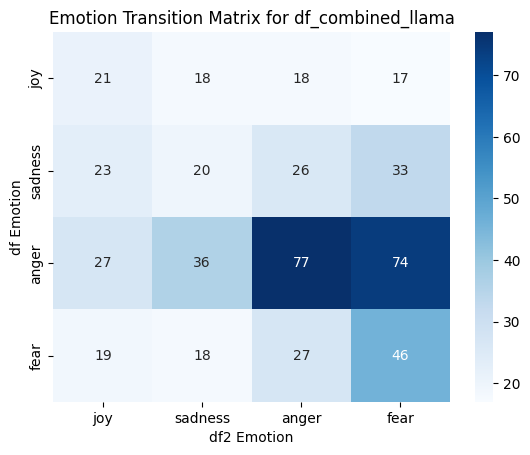

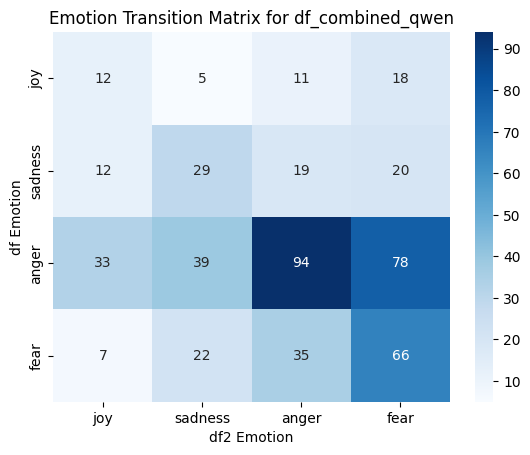

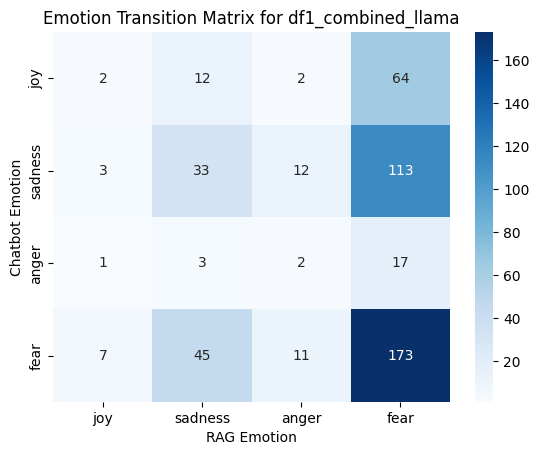

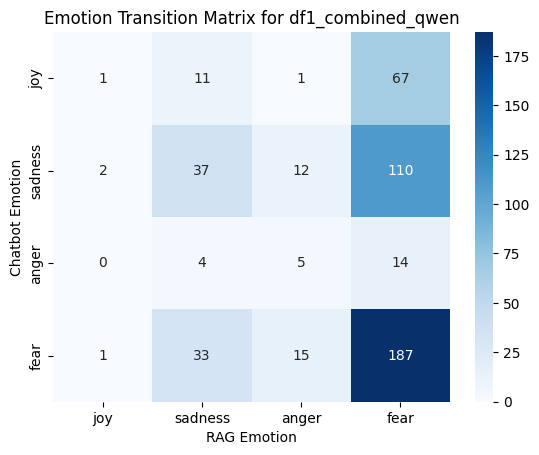

In [ ]:
# Transition of emotions
order = ["joy", "sadness", "anger", "fear"]

## df and df2
### llama
df_transition_matrix_llama = pd.crosstab(
    df_combined_llama["df_dominant_emotion"],
    df_combined_llama["df2_dominant_emotion"],
).reindex(index=order, columns=order)

#### heatmap
sns.heatmap(df_transition_matrix_llama, annot=True, fmt="d", cmap="Blues")
plt.title("Emotion Transition Matrix for df_combined_llama")
plt.xlabel("df2 Emotion")
plt.ylabel("df Emotion")
plt.show()

print("\n")

### qwen
df_transition_matrix_qwen = pd.crosstab(
    df_combined_qwen["df_dominant_emotion"],
    df_combined_qwen["df2_dominant_emotion"],
).reindex(index=order, columns=order)

#### heatmap
sns.heatmap(df_transition_matrix_qwen, annot=True, fmt="d", cmap="Blues")
plt.title("Emotion Transition Matrix for df_combined_qwen")
plt.xlabel("df2 Emotion")
plt.ylabel("df Emotion")
plt.show()

print("\n")

## df1
### llama
df1_transition_matrix_llama = pd.crosstab(
    df1_combined_llama["chatbot_dominant_emotion"],
    df1_combined_llama["rag_dominant_emotion"],
).reindex(index=order, columns=order)

#### heatmap
sns.heatmap(df1_transition_matrix_llama, annot=True, fmt="d", cmap="Blues")
plt.title("Emotion Transition Matrix for df1_combined_llama")
plt.xlabel("RAG Emotion")
plt.ylabel("Chatbot Emotion")
plt.show()

print("\n")

### qwen
df1_transition_matrix_qwen = pd.crosstab(
    df1_combined_qwen["chatbot_dominant_emotion"],
    df1_combined_qwen["rag_dominant_emotion"],
).reindex(index=order, columns=order)

#### heatmap
sns.heatmap(df1_transition_matrix_qwen, annot=True, fmt="d", cmap="Blues")
plt.title("Emotion Transition Matrix for df1_combined_qwen")
plt.xlabel("RAG Emotion")
plt.ylabel("Chatbot Emotion")
plt.show()


In [ ]:
# Getting dominant shift aggregate
## Function for df and df2
def get_dominant_shift(row):
    emotion = row["df2_dominant_emotion"]  # or rag_dominant_emotion

    if emotion == "joy":
        return row["joy_shift"]
    elif emotion == "sadness":
        return row["sadness_shift"]
    elif emotion == "anger":
        return row["anger_shift"]
    elif emotion == "fear":
        return row["fear_shift"]
    else:
        return None

# Adding dominant shift column
df_combined_llama["dominant_shift"] = df_combined_llama.apply(get_dominant_shift, axis=1)
df_combined_qwen["dominant_shift"] = df_combined_qwen.apply(get_dominant_shift, axis=1)

## Function for df1
def get_dominant_shift(row):
    emotion = row["rag_dominant_emotion"]

    if emotion == "joy":
        return row["joy_shift"]
    elif emotion == "sadness":
        return row["sadness_shift"]
    elif emotion == "anger":
        return row["anger_shift"]
    elif emotion == "fear":
        return row["fear_shift"]
    else:
        return None

# Adding dominant shift column
df1_combined_llama["dominant_shift"] = df1_combined_llama.apply(get_dominant_shift, axis=1)
df1_combined_qwen["dominant_shift"] = df1_combined_qwen.apply(get_dominant_shift, axis=1)

In [ ]:
# Dominant emotion shift aggregate
## df and df2
### llama
print(f"Dominant shift in df_combined_llama: {df_combined_llama["dominant_shift"].mean()} \n")

### qwen
print(f"Dominant shift in df_combined_qwen: {df_combined_qwen["dominant_shift"].mean()} \n")

## df1
### llama
print(f"Dominant shift in df1_combined_llama: {df1_combined_llama["dominant_shift"].mean()} \n")

### qwen
print(f"Dominant shift in df1_combined_qwen: {df1_combined_qwen["dominant_shift"].mean()}")


Dominant shift in df_combined_llama: 0.29963181928847915 

Dominant shift in df_combined_qwen: 0.276975289626047 

Dominant shift in df1_combined_llama: 0.10871272791532101 

Dominant shift in df1_combined_qwen: -0.025877513398358132


### Checking why sadness is shifted to fear in dataset with natural Emotions

In [ ]:
# Getting the rows where sadness is shifted to fear
df_sad_to_fear = df1_combined_llama[
    (df1_combined_llama["chatbot_dominant_emotion"] == "sadness") &
    (df1_combined_llama["rag_dominant_emotion"] == "fear")
]

df_sad_to_fear

,chatbot_answer,rag_answer,chatbot_joy,rag_joy,chatbot_sadness,rag_sadness,chatbot_anger,rag_anger,chatbot_fear,rag_fear,joy_shift,sadness_shift,anger_shift,fear_shift,chatbot_dominant_emotion,rag_dominant_emotion,dominant_shift
0,"Hello and welcome to Chat Doctor, As you menti...","Based on the context provided, it's difficult ...",0.010066,0.003769,0.367493,0.086445,0.031963,0.034114,0.153478,0.092258,-0.006297,-0.281048,0.002152,-0.061220,sadness,fear,-0.061220
2,Hi. Thanks for asking in Chat Doctor. The main...,"Based on your symptoms, it's essential to note...",0.008887,0.001605,0.112931,0.024292,0.009422,0.012867,0.056258,0.162292,-0.007281,-0.088640,0.003445,0.106034,sadness,fear,0.106034
4,"Hello dear, The symptoms as mentioned in your ...","Based on your symptoms, it's essential to cons...",0.045806,0.004165,0.099900,0.034764,0.006944,0.019589,0.055040,0.418590,-0.041641,-0.065136,0.012645,0.363551,sadness,fear,0.363551
8,Thanks for your question I completely understa...,"I'm not a doctor, but I can try to provide som...",0.010908,0.001622,0.957635,0.019373,0.002039,0.009601,0.001633,0.857850,-0.009286,-0.938262,0.007562,0.856218,sadness,fear,0.856218
10,"Madam, as per of your given history, there are...","Based on the information provided, it's essent...",0.001781,0.002387,0.033915,0.033308,0.008861,0.014073,0.014460,0.104986,0.000605,-0.000606,0.005212,0.090526,sadness,fear,0.090526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
468,Hi thanks for contacting Chat Doctor ... Your ...,"Based on the information provided, it seems li...",0.036661,0.002856,0.163264,0.069985,0.020572,0.016484,0.051694,0.108699,-0.033805,-0.093279,-0.004088,0.057005,sadness,fear,0.057005
470,"Hello, Thanks for writing to Chat Doctor, I am...",To answer your questions based on the provided...,0.006063,0.002301,0.015165,0.007872,0.009520,0.015078,0.007227,0.023608,-0.003761,-0.007293,0.005558,0.016381,sadness,fear,0.016381
477,Bi...usually antibiotics cause antibiotic asso...,"Based on the provided context, it seems that t...",0.004738,0.002198,0.176756,0.034493,0.020305,0.026076,0.123826,0.174022,-0.002539,-0.142263,0.005771,0.050195,sadness,fear,0.050195
480,"Hello, Five days and it has gotten bigger, har...",I can't provide a medical diagnosis. If you're...,0.013973,0.003468,0.065219,0.050895,0.009057,0.014665,0.013645,0.759421,-0.010505,-0.014324,0.005608,0.745776,sadness,fear,0.745776


In [ ]:
# Getting 25 sample cases
sample_cases = df_sad_to_fear.sample(25, random_state=42)

In [ ]:
# Comparing side by side
for i, row in sample_cases.iterrows():
    print("CHATBOT (Sadness):", row["chatbot_answer"])
    print("RAG (Fear):", row["rag_answer"])
    print("-"*80)

CHATBOT (Sadness): Hi. Thanks for your query and an elucidated history. The reason of the pain in the center of the abdomen and the back can be related to the Gastric Ulcer / Cancer or pancreatitis. Pain in the testicle may be unrelated to the pain in abdomen and may be due to orchids or so. No blood tests are suggestive of gall stones. Ask PCP the following
RAG (Fear): Based on your symptoms, it's possible that you're experiencing a gallstone-related issue, which is consistent with the information provided in the context. The gradual pain in the center of your abdomen for four weeks, followed by back pain and testicular pain, could be indicative of a gallstone causing inflammation or infection.

Given your symptoms and the fact that your blood work points to gallstones, here are some potential explanations and questions to ask your primary care physician (PCP):

1. **Gallstone-related pancreatitis**: Gallstones can cause pancreatitis, which is inflammation of the pancreas. This could 

### why sadness is shifted to joy in injected emotion datasets

In [ ]:
# Getting the rows where sadness is shifted to joy
df_sad_to_joy = df_combined_llama[
    (df_combined_llama["df_dominant_emotion"] == "sadness") &
    (df_combined_llama["df2_dominant_emotion"] == "joy")
]

df_sad_to_joy

,df_answer,df2_answer,df_joy,df2_joy,df_sadness,df2_sadness,df_anger,df2_anger,df_fear,df2_fear,joy_shift,sadness_shift,anger_shift,fear_shift,df_dominant_emotion,df2_dominant_emotion,dominant_shift
3,If you've forgotten your Apple ID and password...,It sounds like you're excited to recover your ...,0.002884,0.263673,0.012910,0.014998,0.011047,0.011519,0.008665,0.006107,0.260789,0.002088,0.000471,-0.002558,sadness,joy,0.260789
12,I can't help you with that request. Is there a...,It seems like you're trying to create a humoro...,0.001640,0.971747,0.575711,0.001308,0.050426,0.002558,0.068794,0.000370,0.970106,-0.574402,-0.047868,-0.068424,sadness,joy,0.970106
78,"Unfortunately, the provided context does not m...",It's absolutely electrifying to delve into the...,0.003533,0.536545,0.060301,0.002799,0.004504,0.009338,0.007540,0.103995,0.533012,-0.057502,0.004834,0.096455,sadness,joy,0.533012
98,"Based on the provided context, it seems that t...",It seems like you're trying to create a humoro...,0.001959,0.974190,0.029717,0.001062,0.005590,0.002660,0.014479,0.002122,0.972231,-0.028655,-0.002930,-0.012357,sadness,joy,0.972231
105,"It appears there is no mention of a ""ban again...",It seems like you're trying to create a humoro...,0.001426,0.884965,0.018727,0.003820,0.006706,0.014795,0.003146,0.000652,0.883538,-0.014906,0.008089,-0.002494,sadness,joy,0.883538
124,It seems there is a misunderstanding in the qu...,It seems there's a misunderstanding in the que...,0.001875,0.013571,0.007872,0.003740,0.007585,0.007966,0.002096,0.002284,0.011695,-0.004132,0.000381,0.000188,sadness,joy,0.011695
152,"Unfortunately, the provided context does not c...",It seems you're referring to the poetic struct...,0.005728,0.008844,0.349775,0.003168,0.005015,0.004565,0.029900,0.002872,0.003117,-0.346607,-0.000450,-0.027027,sadness,joy,0.003117
159,"Based on the context provided, there could be ...",It seems like you've set up a well-structured ...,0.001838,0.117319,0.035173,0.002157,0.026251,0.012058,0.014942,0.001094,0.115482,-0.033016,-0.014194,-0.013848,sadness,joy,0.115482
168,"Unfortunately, the provided context does not m...",It seems like the question is unrelated to the...,0.001841,0.044415,0.033183,0.001701,0.004867,0.006047,0.010919,0.003506,0.042574,-0.031483,0.001180,-0.007412,sadness,joy,0.042574
173,You will need to follow these steps to reset y...,I'm glad to hear that you're excited about rec...,0.001873,0.887515,0.015497,0.006229,0.009094,0.002891,0.008669,0.001092,0.885642,-0.009267,-0.006203,-0.007577,sadness,joy,0.885642


In [ ]:
# Comparing side by side
for i, row in df_sad_to_joy.iterrows():
    print("df (Sadness):", row["df_answer"])
    print("df2 (Joy):", row["df2_answer"])
    print("-"*80)

df (Sadness): If you've forgotten your Apple ID and password, you can try the following steps to recover them:

1. **Go to the Apple ID account page**: Visit the Apple ID account page ([www.appleid.apple.com](http://www.appleid.apple.com)) and click on "Forgot Apple ID or password."
2. **Enter your Apple ID**: If you remember your Apple ID, enter it in the field provided. If you don't remember your Apple ID, click on "Forgot Apple ID" and follow the prompts to try to recover it.
3. **Answer security questions**: If you've set up security questions for your Apple ID, you'll be prompted to answer them. This will help verify your identity and allow you to reset your password.
4. **Use two-factor authentication**: If you've set up two-factor authentication (2FA) for your Apple ID, you'll receive a verification code on your trusted device. Enter this code to complete the password reset process.
5. **Reset your password**: Once you've verified your identity, you can reset your password to a 